# Notebook: 06 Benchmark Models
### Purpose: benchmark segmentation models on a shared dataset and compare quality and speed.

In [9]:
import os
import sys


sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

import time
import matplotlib.pyplot as plt
import pandas as pd
import torch
from src.data.annotations import load_json_annotations
from src.data.augmentations import get_val_augmentations
from src.data.loaders import ImageMaskDataset
from src.models.zoo import build_model, MODEL_BENCHMARKS
from src.training.metrics import compute_metrics
from src.utils.config import Config
from src.utils.helpers import init_notebook, p


config = Config.load()

init_notebook(config.train.seed)

train_dir = config.paths.train_images
annotations_path = config.paths.annotations
entries = load_json_annotations(annotations_path)


=== init_notebook ===
Done


#### Load validation entries

In [2]:
val_count = max(8, int(0.1 * len(entries)))
val_entries = entries[:val_count]

val_tf = get_val_augmentations(config.train.image_size)
val_ds = ImageMaskDataset(val_entries, train_dir, transform = val_tf)

p("Validation samples", len(val_ds))

Validation samples: 15


#### Model definitions

In [3]:
p("Models", MODEL_BENCHMARKS)
#config.show()
p("Batch", config.train.batch_size)
p("Epochs", config.train.epochs)
p("Learning Rate", config.train.learning_rate, precision = 9)
p("Image Size", config.train.image_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Models: 12 keys
  simple_cnn:
  unet:
  smp_unet:
    encoder_name: resnet34
  smp_fpn:
    encoder_name: resnet34
  smp_linknet:
    encoder_name: resnet34
  smp_deeplabv3:
    encoder_name: resnet34
  smp_deeplabv3plus:
    encoder_name: resnet34
  segformer:
    model_name: nvidia/segformer-b0-finetuned-ade-512-512
  yolov8n:
  yolov8s:
  yolov8m:
  yolov8l:
Batch: 8
Epochs: 2
Learning Rate: 0.010000000
Image Size: 224


#### Benchmarking

In [4]:
rows = []

for name, params in MODEL_BENCHMARKS.items():
    p("Testing model", name)

    try:
        model = build_model(name, in_channels = 3, out_channels = 3, **params).to(device)


    except Exception as e:
        p("Failed to load model", name)
        p("Error", e)
        continue

    model.eval()

    total_iou = 0.0
    total_dice = 0.0
    total_acc = 0.0
    total_time = 0.0

    start_mem = torch.cuda.memory_allocated(device) if device.type == "cuda" else 0

    with torch.no_grad():
        for img_t, mask_t in val_ds:
            img_t = img_t.unsqueeze(0).to(device)
            mask_t = mask_t.unsqueeze(0).to(device)

            t0 = time.time()
            pred = model(img_t)
            t1 = time.time()

            total_time += (t1 - t0)

            m = compute_metrics(pred, mask_t)
            total_iou += m["iou"]
            total_dice += m["dice"]
            total_acc += m["acc"]

    n = len(val_ds)
    end_mem = torch.cuda.memory_allocated(device) if device.type == "cuda" else 0
    mem_used = end_mem - start_mem
    params_num = sum(p.numel() for p in model.parameters())

    rows.append(
            {
                "model":         name,
                "params":        params_num,
                "avg_iou":       total_iou / n,
                "avg_dice":      total_dice / n,
                "avg_acc":       total_acc / n,
                "avg_time_sec":  total_time / n,
                "gpu_mem_bytes": int(mem_used),
            }
    )

df = pd.DataFrame(rows)
df

Testing model: simple_cnn
Testing model: unet
Testing model: smp_unet
Testing model: smp_fpn
Testing model: smp_linknet
Testing model: smp_deeplabv3
Testing model: smp_deeplabv3plus
Testing model: segformer


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([3]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([3, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing model: yolov8n
Testing model: yolov8s
Testing model: yolov8m
Testing model: yolov8l


,model,params,avg_iou,avg_dice,avg_acc,avg_time_sec,gpu_mem_bytes
0,simple_cnn,38211,0.142115,0.241772,0.573275,0.015728,1605632
1,unet,31043651,0.198726,0.310499,0.198726,0.007887,0
2,smp_unet,24436659,0.192324,0.303931,0.272150,0.010899,0
3,smp_fpn,23155651,0.127110,0.220883,0.645363,0.013318,0
4,smp_linknet,21772003,0.147492,0.249108,0.536424,0.010335,0
5,smp_deeplabv3,26007619,0.169065,0.276179,0.413191,0.012005,0
6,smp_deeplabv3plus,22437971,0.196567,0.307919,0.202922,0.008646,0
7,segformer,3714915,0.132569,0.223056,0.509684,0.018440,7955456
8,yolov8n,1183587,0.010464,0.020639,0.795310,0.010112,564224
9,yolov8s,4720323,0.198726,0.310499,0.198728,0.007155,0


#### Plot IoU, Speed, Memory

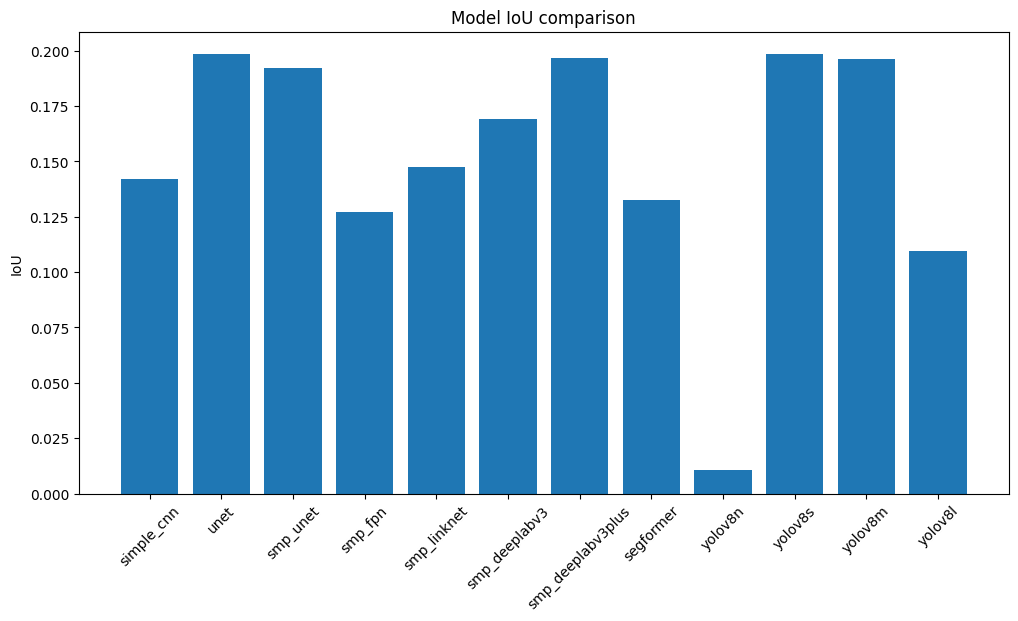

In [5]:
# IoU bar chart
plt.figure(figsize = (12, 6))
plt.bar(df["model"], df["avg_iou"])
plt.xticks(rotation = 45)
plt.ylabel("IoU")
plt.title("Model IoU comparison")
plt.show()


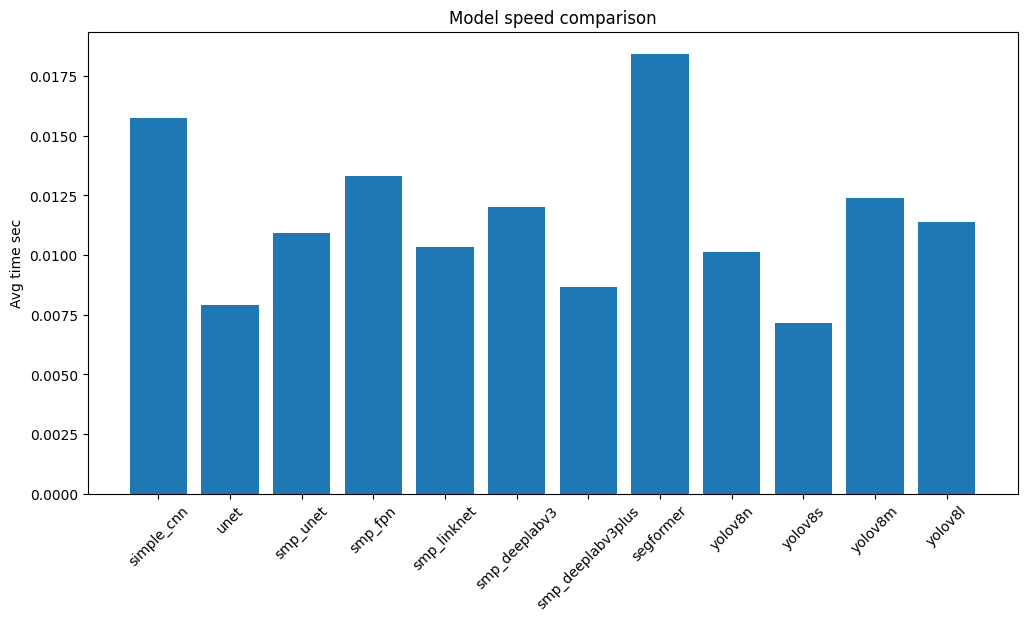

In [6]:
# speed bar chart
plt.figure(figsize = (12, 6))
plt.bar(df["model"], df["avg_time_sec"])
plt.xticks(rotation = 45)
plt.ylabel("Avg time sec")
plt.title("Model speed comparison")
plt.show()

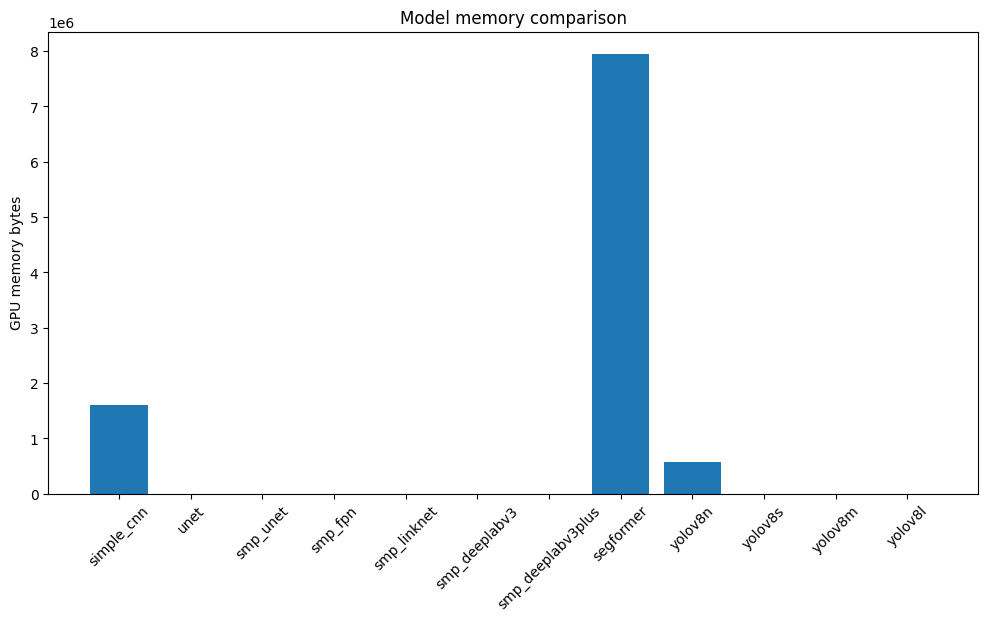

In [7]:
# memory chart
plt.figure(figsize = (12, 6))
plt.bar(df["model"], df["gpu_mem_bytes"])
plt.xticks(rotation = 45)
plt.ylabel("GPU memory bytes")
plt.title("Model memory comparison")
plt.show()

#### Export benchmark results

In [8]:
out_path = config.paths.models / "benchmark_results.csv"
df.to_csv(out_path, index = False)
p("Saved", out_path)

Saved: C:\github\Tree-Canopy-Detection\checkpoints\benchmark_results.csv
